# 02 · Evaluation

How well each recognition model does, read from the committed `evaluation/results.json` only. Nothing here touches raw data or model weights; `uv run ryuk evaluate lfw` computes the numbers. Protocol and thresholds follow the evaluation protocol decision (#9).

This notebook begins with verification on LFW. Open-set identification on CelebA follows once its test draw has been scored.

In [1]:
%matplotlib inline
from pathlib import Path

from IPython.display import Markdown, display

from ryuk.evaluation.figures import lfw_roc
from ryuk.evaluation.results import Results
from ryuk.evaluation.tables import lfw_markdown, model_name

here = Path.cwd().resolve()
root = next(p for p in (here, *here.parents) if (p / "evaluation" / "results.json").is_file())
results = Results.model_validate_json((root / "evaluation" / "results.json").read_bytes())
verification = results.verification
provenance = verification.provenance
print(
    f"commit {provenance.commit[:12]}{' (dirty)' if provenance.dirty else ''}, "
    f"{provenance.generated_at:%Y-%m-%d %H:%M} UTC, {provenance.machine}"
)

commit 32b79bbc8bb3, 2026-09-25 18:29 UTC, macOS-27.0-arm64-arm-64bit (arm64)


## Verification on LFW

LFW View 2 (`pairs.txt`): 6,000 pairs in 10 folds of 300 matched and 300 mismatched. Each image goes through YuNet, the centre-most usable face, a crop and the model. The score is the cosine of the two L2-normalised embeddings. The threshold for each fold is the best on the other nine, over InsightFace's grid, which is the OpenCV zoo / InsightFace recipe the published figures use. Accuracy is the mean over folds, ± the standard error LFW defines (fold standard deviation over √10). AUC and TAR at FAR come from all scored pairs pooled, accepting a pair at or above a threshold, as the live monitor does.

A model more than 0.5 points from its published figure is flagged ⚑. That is a pipeline bug to find, not a result, and it makes the model ineligible to be the first active one.

**Table 1 · Verification on LFW**

In [2]:
display(Markdown(lfw_markdown(verification)))

| Model | Embedding size | Published LFW | Our LFW (± SE) | AUC | TAR @ FAR 1% | TAR @ FAR 0.1% (indicative) |
|---|---:|---:|---:|---:|---:|---:|
| SFace | 128 | 99.40 | 99.38 ± 0.12 | 0.9977 | 99.33 | 98.35 |
| ArcFace (CoreML) | 512 | 99.83 | 99.78 ± 0.08 | 0.9990 | 99.70 | 99.63 |
| FaceNet | 512 | 99.65 | 99.36 ± 0.11 | 0.9987 | 99.36 | 97.94 |

LFW View 2, 5,917 of 6,000 pairs scored, in 10 folds, threshold per fold chosen on the other nine. Accuracy and TAR in percent.

58 images had no usable face, so 83 pairs using them are not scored; the published recipes score every pair. Counting each unscored pair as an error: SFace 98.00, ArcFace (CoreML) 98.40, FaceNet 97.98.

ArcFace (CoreML): The buffalo_l pack's figure. The same README's row for the standalone R50 WebFace600K model says 99.80.

FaceNet: 99.65 ± 0.25, measured on MTCNN crops with a margin of 32 and flipped-image averaging. Ryuk uses a YuNet crop and no flip, so a small shortfall is expected.

SFace int8 is not a row. On macOS-27.0-arm64-arm-64bit (arm64) it scores 99.12 ± 0.13, takes 11.4 ms per face against fp32's 4.1 ms, and its embeddings drift from fp32's (cosine 0.971 on average, 0.930 at worst, over 7,643 faces). It is built for memory-constrained, integer-accelerated hardware this machine is not. crimdet shipped int8; Ryuk does not. The block-quantised int8bq variant does not load on OpenCV 5's default engine at all (#7).

**Figure 1 · LFW View 2 ROC.** True accept rate against false accept rate for every model, on a log FAR axis. The curves start at FAR 10⁻⁴, since 3,000 negative pairs cannot resolve anything smaller.

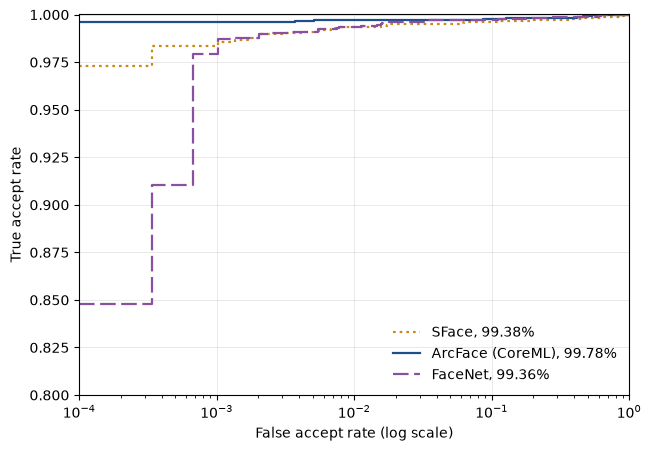

In [3]:
lfw_roc(verification)

## Pipeline choices on View 1

Choices are made on View 1 (`pairsDevTrain` for the threshold, `pairsDevTest` for accuracy), never on View 2. The one choice so far is FaceNet's crop: YuNet's five-point alignment resized to 160, or the YuNet box widened by a margin as facenet-pytorch does, 14 pixels (its default) or 32 (the margin FaceNet's published figure used). Only the winner is scored on View 2.

In [4]:
rows = [
    "| Network | Crop | Threshold | DevTest accuracy | Chosen |",
    "|---|---|---:|---:|:---:|",
]
for t in verification.view_1:
    chosen = "✓" if t.chosen else ""
    rows.append(
        f"| {t.network} | {t.crop} | {t.threshold:.3f} | {t.accuracy * 100:.2f} | {chosen} |"
    )
display(Markdown("\n".join(rows)))

| Network | Crop | Threshold | DevTest accuracy | Chosen |
|---|---|---:|---:|:---:|
| facenet | five-point | 0.410 | 98.17 |  |
| facenet | box-margin-14 | 0.430 | 98.78 |  |
| facenet | box-margin-32 | 0.470 | 99.29 | ✓ |

## Per-fold detail

In [5]:
for model in verification.models:
    folds = ", ".join(f"{f.accuracy * 100:.2f}" for f in model.folds)
    print(f"{model_name(model.model):18} {model.crop:14} folds: {folds}")
print(
    f"\n{len(verification.excluded_images)} images without a usable face:",
    ", ".join(verification.excluded_images) or "none",
)

SFace              five-point     folds: 99.49, 99.83, 99.66, 99.15, 98.66, 99.66, 98.99, 99.49, 99.15, 99.66
ArcFace (CoreML)   five-point     folds: 99.66, 100.00, 100.00, 99.66, 99.50, 100.00, 99.66, 100.00, 99.32, 100.00
FaceNet            box-margin-32  folds: 99.66, 99.49, 98.82, 99.66, 99.16, 99.49, 98.99, 99.66, 98.98, 99.66

58 images without a usable face: Adrian_McPherson/Adrian_McPherson_0001.jpg, Alan_Greenspan/Alan_Greenspan_0001.jpg, Alek_Wek/Alek_Wek_0001.jpg, Allan_Houston/Allan_Houston_0001.jpg, Alvaro_Uribe/Alvaro_Uribe_0014.jpg, Andy_Roddick/Andy_Roddick_0008.jpg, Arminio_Fraga/Arminio_Fraga_0001.jpg, Brandon_Spann/Brandon_Spann_0001.jpg, Chloe_Sevigny/Chloe_Sevigny_0001.jpg, Chung_Mong-hun/Chung_Mong-hun_0001.jpg, Clive_Lloyd/Clive_Lloyd_0001.jpg, Courtney_Love/Courtney_Love_0001.jpg, David_Westerfield/David_Westerfield_0001.jpg, Emanuel_Ginobili/Emanuel_Ginobili_0002.jpg, Fatma_Kusibeh/Fatma_Kusibeh_0001.jpg, Fernando_Henrique_Cardoso/Fernando_Henrique_Cardoso_000